In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
import cv2

In [4]:
from segment_anything import SamPredictor,sam_model_registry
model_name = 'vit_b'
model_path = 'D:/Projects/Minor Project/Parameters/SAM-Parameter/sam_vit_b_01ec64.pth'

test_image_path = 'D:/Projects/Minor Project/Datasets/raw/testings_images/'

image = cv2.imread(test_image_path + "dog2.jpg")
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
print(image.shape)

sam = sam_model_registry[model_name](checkpoint=model_path)
predictor = SamPredictor(sam)
predictor.set_image(image)
image_embeddings = predictor.get_image_embedding()

scaled_h,scaled_w = predictor.input_size

features_h = scaled_h // 16
features_w = scaled_w // 16

valid_features = image_embeddings[:,:,:features_h,:features_w]

(430, 710, 3)


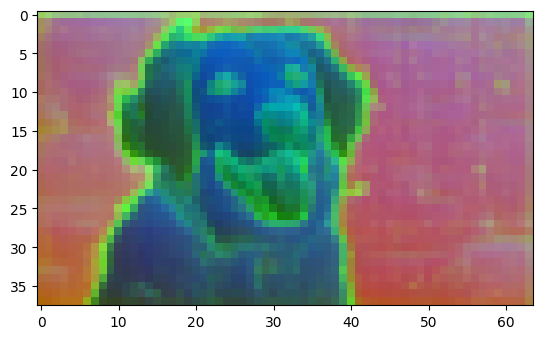

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

features = valid_features.cpu().numpy().reshape(256,-1).T

features_rgb = pca.fit_transform(features)

features_rgb = (features_rgb - features_rgb.min()) / (features_rgb.max() - features_rgb.min())\

features_rgb = features_rgb.reshape(features_h,features_w,3)

plt.imshow(features_rgb)

In [ ]:
from nuscenes.utils.geometry_utils import view_points
from nuscenes.nuscenes import NuScenes,NuScenesExplorer
from nuscenes.utils.data_classes import LidarPointCloud
from pyquaternion import Quaternion
import os

data_path = 'D:/Projects/Minor Project/Datasets/raw/nuScenes'

In [ ]:
nusc = NuScenes(version='v1.0-mini',dataroot=data_path,verbose=True)
explorer = NuScenesExplorer(nusc)

my_sample = nusc.sample[87]

cam_token = my_sample['data']["CAM_FRONT"]
lidar_token = my_sample['data']["LIDAR_TOP"]

points,coloring,image = explorer.map_pointcloud_to_image(lidar_token,cam_token)

print(points)
print(coloring)

explorer.render_pointcloud_in_image(my_sample['token'],dot_size=5,render_intensity=False,show_lidarseg=True)

In [ ]:
depth_map = np.zeros((2,64,64),dtype=np.float32)

u_cord = points[0,:]
v_cord = points[1,:]

scaled_u = 64/1600
scaled_v = 64/900

for i in range(len(coloring)):
    u = int(u_cord[i] * scaled_u)
    v = int(v_cord[i] * scaled_v)

    if 0 <= u < 64 and 0 <= v < 64:
        depth_map[0,v,u] = coloring[i]
        depth_map[1,v,u] = 1.0

depth_tensor = torch.from_numpy(depth_map).unsqueeze(0)
print(coloring)
print(depth_tensor.shape)

In [ ]:
class DepthEncoder(nn.Module):
    def __init__(self,in_channel = 2, embeddings_channel = 256):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channel,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.final_projection = nn.Conv2d(256,embeddings_channel,kernel_size=1)


    def forward(self,x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        return self.final_projection(x)

depth_encoder = DepthEncoder()

In [ ]:
import sys
import os

# 1. Get the current directory (Minor Project/Notebook)
# 2. Get the parent directory (Minor Project)
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

# 3. Add that parent directory to sys.path
if root_path not in sys.path:
    sys.path.append(root_path)